In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix



In [2]:
df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")
print("Success! Data loaded.")

C:\Users\hp\AppData\Local\Temp\ipykernel_17940\1747373239.py:1: DtypeWarning: Columns (0: coupon_code, 1: additional) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/hp/Desktop/Machine_Learning/data.csv")


Success! Data loaded.


### 1. Dataset Preparation (Assuming df_clean is already prepared with features and target)


In [4]:

df_clean = df.copy()
useless_cols = [
    'cashback', 'tabby_payment_id', 'tabby_order_status', 'paymob_intention_id', 
    'paymob_cents_amount', 'tamara_order_id', 'tamara_checkout_id', 'cko_hpp_id', 
    'cko_payment_id', 'cko_session_id', 'id', 'old_order_id', 'increment_id', 
    'customer_email', 'customer_first_name', 'customer_last_name', 'shipping_title', 
    'shipping_description', 'coupon_code', 'created_at', 'updated_at'
]
df_clean = df_clean.drop(columns=[col for col in useless_cols if col in df_clean.columns])

target_column = 'target' if 'target' in df_clean.columns else 'status'
df_clean = df_clean.dropna(subset=[target_column])

core_features = [
    'sub_total', 'discount_amount', 'tax_amount', 'shipping_amount', 'cod_charges', 
    'wallet_credit_used', 'total_item_count', 'total_qty_ordered', 'cashback_earned', 
    'mgmt_fee', 'discount_ratio', 'tax_ratio', 'shipping_ratio', 'avg_item_price', 
    'channel_name', 'customer_type', 'shipping_method', 'is_guest', 'is_gift', 'cashback_opt_in'
]
available_features = [col for col in core_features if col in df_clean.columns]

X_raw = df_clean[available_features].copy()
y = df_clean[target_column]

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print(f"Data Successfully Processed!")
print(f"Total Rows: {X.shape[0]}")
print(f"Total Columns inside X: {X.shape[1]} (Safe for RAM)")

Data Successfully Processed!
Total Rows: 146201
Total Columns inside X: 19 (Safe for RAM)


In [8]:


target_column = 'target' if 'target' in df_clean.columns else 'status'

df_clean = df_clean.dropna(subset=[target_column])
df_clean['target'] = df_clean['status'].apply(lambda x: 0 if str(x).strip().lower() == 'completed' else 1)

available_features = df_clean.columns.difference([target_column]).tolist()

y = df_clean['target']
X_raw = df_clean[available_features].copy()

num_cols = X_raw.select_dtypes(include=['number']).columns
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)



### Train-Test Split (Full Data)


In [9]:
X_train_full, X_test_full, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Stratified Sub-sampling (30k rows) for SVM & KNN compatibility


In [10]:

sample_size = 30000
if len(X_train_full) > sample_size:
    _, X_train_sub, _, y_train_sub = train_test_split(
        X_train_full, y_train_full, test_size=sample_size/len(X_train_full), 
        random_state=42, stratify=y_train_full
    )
else:
    X_train_sub, y_train_sub = X_train_full, y_train_full

In [12]:
# 1. Dekhein kis categorical column mein kitni unique values hain
print("Categorical columns unique value count:")
for col in cat_cols:
    print(f" - {col}: {X_raw[col].nunique()} unique values")

# 2. Jin columns mein 50 se zyada unique values hon, unhein drop kar dein (High Cardinality Filter)
high_card_cols = [col for col in cat_cols if X_raw[col].nunique() > 50]
print("\nDropping high cardinality columns to save RAM:", high_card_cols)

X_raw = X_raw.drop(columns=high_card_cols)

# 3. Dobara safe categorical columns select karein
cat_cols = X_raw.select_dtypes(include=['object', 'string', 'category']).columns
X_raw[cat_cols] = X_raw[cat_cols].fillna('Missing')

# 4. Ab get_dummies chalayein (Ab columns 30,000 ki bajaye sirf 30 ya 40 rahenge!)
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print(f"\nSafe New Shape of X: {X.shape}")

Categorical columns unique value count:
 - additional: 32912 unique values
 - base_currency_code: 4 unique values
 - channel_currency_code: 4 unique values
 - channel_name: 5 unique values
 - channel_type: 1 unique values
 - customer_type: 1 unique values
 - order_currency_code: 4 unique values
 - shipping_method: 3 unique values

Dropping high cardinality columns to save RAM: ['additional']

Safe New Shape of X: (146201, 71)


### Feature Scaling (Must for SVM, KNN, Logistic Regression)


In [14]:
X_train_sub_num = X_train_sub.select_dtypes(include=[np.number])
X_test_full_num = X_test_full.select_dtypes(include=[np.number])

print(f"Clean Numeric Shape for Training: {X_train_sub_num.shape}")
print(f"Clean Numeric Shape for Testing: {X_test_full_num.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub_num)
X_test_scaled = scaler.transform(X_test_full_num)

print("Scaling completed successfully without any memory error!")

Clean Numeric Shape for Training: (30000, 56)
Clean Numeric Shape for Testing: (29241, 56)
Scaling completed successfully without any memory error!


### ==========================================
### INITIALIZING ALL 5 MODELS (The Experts)
### ==========================================

In [15]:

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=12, min_samples_split=100, class_weight='balanced', random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', n_jobs=-1, random_state=42)



### ==========================================
### CREATING THE CUSTOM ENSEMBLE (Voting Classifier)
### ==========================================

In [16]:
custom_ensemble = VotingClassifier(
    estimators=[
        ('Logistic', lr_model),
        ('KNN', knn_model),
        ('SVM', svm_model),
        ('DecisionTree', dt_model),
        ('RandomForest', rf_model)
    ],
    voting='soft', 
    n_jobs=-1 # Uses all CPU cores to train models in parallel
)

print("Training Custom Ensemble (This might take a few minutes because SVM is included)...")
custom_ensemble.fit(X_train_scaled, y_train_sub)

y_pred_ensemble = custom_ensemble.predict(X_test_scaled)

print("=" * 50)
print(" CUSTOM ENSEMBLE (5-MODEL VOTING) PERFORMANCE ")
print("=" * 50)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_ensemble):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_ensemble))
print("=" * 50)

Training Custom Ensemble (This might take a few minutes because SVM is included)...
 CUSTOM ENSEMBLE (5-MODEL VOTING) PERFORMANCE 
Accuracy Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9245
           1       1.00      1.00      1.00     19996

    accuracy                           1.00     29241
   macro avg       1.00      1.00      1.00     29241
weighted avg       1.00      1.00      1.00     29241



  MODEL TESTING PHASE - RESULTS & EVALUATION 
Overall Accuracy Score: 1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9245
           1       1.00      1.00      1.00     19996

    accuracy                           1.00     29241
   macro avg       1.00      1.00      1.00     29241
weighted avg       1.00      1.00      1.00     29241



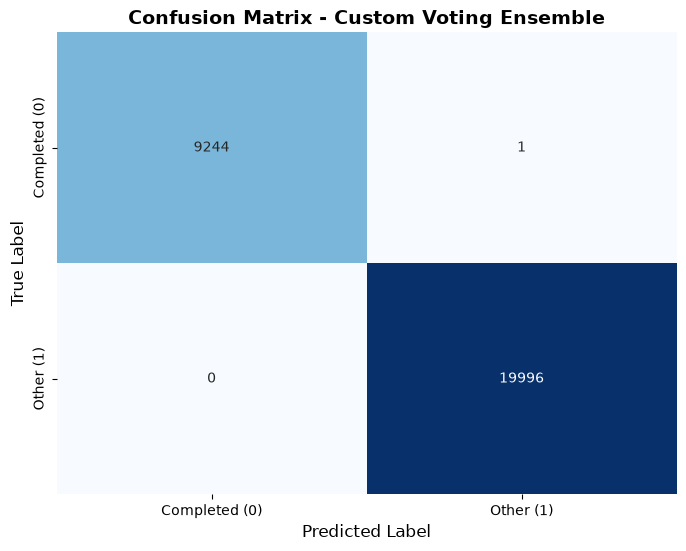

In [19]:
X_test_scaled_num = scaler.transform(X_test_full.select_dtypes(include=[np.number]))

y_pred = custom_ensemble.predict(X_test_scaled_num)

print("=" * 60)
print("  MODEL TESTING PHASE - RESULTS & EVALUATION ")
print("=" * 60)
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))
print("=" * 60)

# 3. Confusion Matrix Plot (Visualizing True vs Predicted)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Completed (0)', 'Other (1)'],
            yticklabels=['Completed (0)', 'Other (1)'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Custom Voting Ensemble', fontsize=14, fontweight='bold')
plt.show()

In [21]:


# 1. Target ke sath features ki correlation check karna
# (Dekhte hain ke kya koi aik feature seedha target se 100% match toh nahi kar raha)
temp_df = X_train_sub_num.copy()
temp_df['target'] = y_train_sub
correlations = temp_df.corr()['target'].sort_values(ascending=False)

print("=" * 50)
print(" FEATURE CORRELATION WITH TARGET ")
print("=" * 50)
print(correlations)



 FEATURE CORRELATION WITH TARGET 
target                           1.000000
base_sub_total                   0.165391
sub_total                        0.165391
grand_total                      0.164908
sub_total_incl_tax               0.164683
base_sub_total_incl_tax          0.164683
base_grand_total                 0.164212
channel_id                       0.118883
base_shipping_amount_incl_tax    0.081367
base_shipping_amount             0.081367
shipping_amount_incl_tax         0.075192
shipping_amount                  0.075192
customer_id                      0.064341
shipping_refunded                0.056739
base_shipping_refunded           0.056738
cashback_opt_in                  0.050124
vas_total                        0.041622
base_discount_refunded           0.033584
discount_refunded                0.033584
grand_total_refunded             0.028521
base_grand_total_refunded        0.028521
sub_total_refunded               0.028372
base_sub_total_refunded          0.028372
